# **Análisis de Marketing y Comunicación - Contáctos telefónicos éxitosos**


---

**Proyecto:** Equip_27 - Bank Atlas. 

**Equipo:** Analistas de Marketing y Comunicación. 

**Pregunta:** Qué relación hay entre el número de contactos realizados durante esta campaña y la tasa de éxito, y como podemos optimizar la frecuencia de contactos para maximizar los resultados de nuestras campañas de marketing?

---

**Técnica:** Análisis descriptivo(EDA) con agrupación (GROUPBY) y relaciones entre variables con cálculo de proporciones  para analizar tasa de éxito en función del número de contactos.
*Variables:* 'campaign' y 'deposit'.

---

# =========================
# ANÁLISIS SEMANA 260420
# =========================

## **1- Imports, ubicación y carga de datos**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
import os
print(os.getcwd())
print(os.listdir("../../Data"))

/Users/fedecrs/ProjecteData/Equip_27/Scripts/260504
['.DS_Store', 'df_original_260504.csv', 'df_limpiado_260504.parquet', 'df_limpiado_260420.parquet', 'README.md', 'df_original_260420.csv', 'df_original_260427.csv', 'df_limpiado_260427.parquet']


In [3]:
df_260420 = pd.read_parquet("../../Data/df_limpiado_260420.parquet")

df_marketing = df_260420.copy()

df_marketing.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,contactado_campania_previa
0,59.0,administration,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,NaN,0,sin_campania_previa,yes,0
1,56.0,administration,married,secondary,no,45,no,no,unknown,5,may,1467,1,NaN,0,sin_campania_previa,yes,0
2,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,NaN,0,sin_campania_previa,yes,0
3,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,NaN,0,sin_campania_previa,yes,0
4,54.0,administration,married,tertiary,no,184,no,no,unknown,5,may,673,2,NaN,0,sin_campania_previa,yes,0


## **2- Exploración de variables**

In [4]:
df_marketing[['campaign', 'deposit']].head(15)

,campaign,deposit
0,1,yes
1,1,yes
2,1,yes
3,1,yes
4,2,yes
5,2,yes
6,1,yes
7,1,yes
8,1,yes
9,3,yes


In [5]:
# Variable derivada para análisis de conversión

if "deposit_bin" not in df_marketing.columns:

    df_marketing["deposit_bin"] = (
        df_marketing["deposit"]
        .map({
            "yes": 1,
            "no": 0
        })
    )

Tasa de éxito por número de contactos

## **3- Análisis principal (Relación 'campaign' vs 'deposit')**

In [6]:
success_rate = (
    df_marketing.groupby('campaign')['deposit']
    .value_counts(normalize=True)
    .unstack()
)

success_rate

deposit,no,yes
campaign,,
1,0.459819,0.540181
2,0.527965,0.472035
3,0.524981,0.475019
4,0.582345,0.417655
5,0.624324,0.375676
6,0.639216,0.360784
7,0.656934,0.343066
8,0.746032,0.253968
9,0.708333,0.291667


contactos vs probabilidad de éxito

## **4- Visualización**

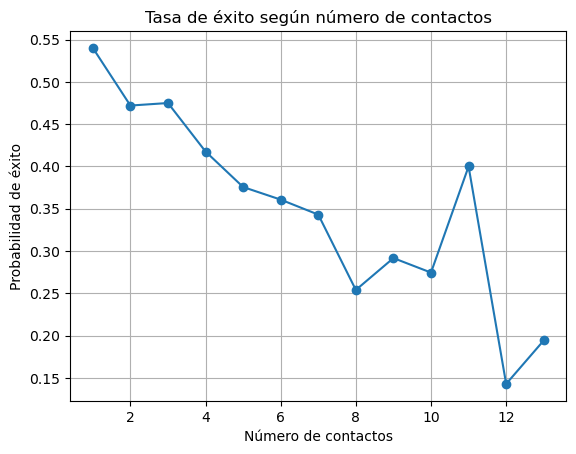

In [7]:
success_rate['yes'].plot(marker='o')
plt.title("Tasa de éxito según número de contactos")
plt.xlabel("Número de contactos")
plt.ylabel("Probabilidad de éxito")
plt.grid()
plt.show()

## **4- Agrupación de contactos**

In [8]:
def agrupar_contactos(x):
    if x <= 2:
        return "Bajo"
    elif x <= 5:
        return "Medio"
    else:
        return "Alto"

df_marketing['grupo_contacto'] = df_marketing['campaign'].apply(agrupar_contactos)

## **6- Visualización agrupada**

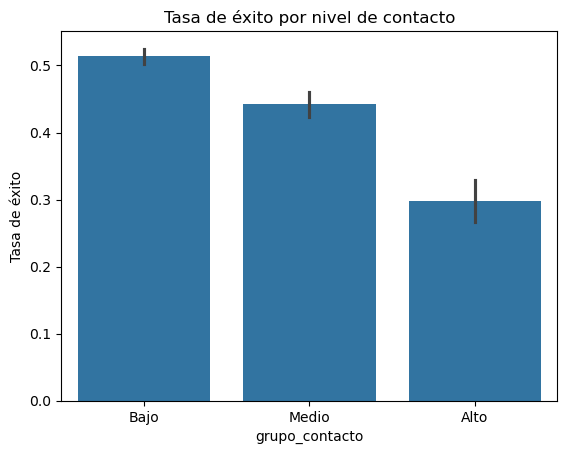

In [9]:
sns.barplot(
    data=df_marketing,
    x='grupo_contacto',
    y=(df_marketing['deposit'] == 'yes').astype(int)
)

plt.title("Tasa de éxito por nivel de contacto")
plt.ylabel("Tasa de éxito")
plt.show()

## **7- Visualización del análisis de distribución**

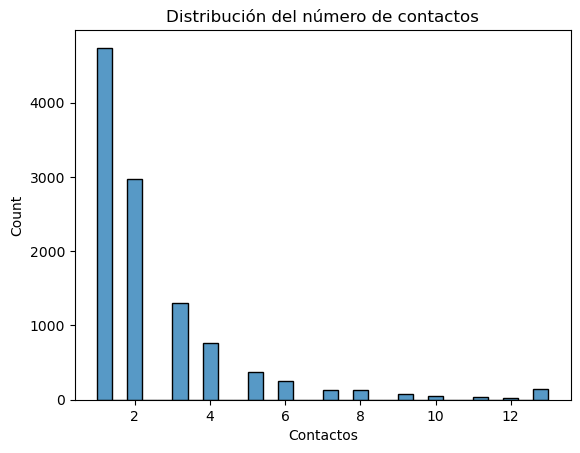

In [10]:
sns.histplot(df_marketing['campaign'], bins=30)
plt.title("Distribución del número de contactos")
plt.xlabel("Contactos")
plt.show()

## **8- Conclusiones**

- Se observa una relación negativa entre el número de contactos y la tasa de éxito.
- Los clientes con pocos contactos presentan mayor probabilidad de conversión, mientras que un exceso de contactos reduce la eficacia de la campaña, indicando un posible efecto de saturación.

## **9- Recomendaciones**

- Se recomienda optimizar la frecuencia de contacto priorizando la calidad sobre la cantidad, y evitando sobrecontactar a los clientes para maximizar la tasa de conversión.

## **10- KPI's**

In [11]:
# KPI: conversión por número de contactos
conversion = (
    df_marketing.groupby("campaign")["deposit_bin"]
    .mean()
    .mul(100)
    .reset_index()
)

conversion.columns = ["num_contactos", "tasa_conversion"]

# KPI principal
best_row = conversion.loc[conversion["tasa_conversion"].idxmax()]
best_contactos = int(best_row["num_contactos"])
best_conversion = round(best_row["tasa_conversion"], 2)

# KPI global
conversion_global = round(df_marketing["deposit_bin"].mean() * 100, 2)

# OUTPUT FINAL
print(" KPI PRINCIPAL")
print(f"Conversión máxima: {best_conversion}% con {best_contactos} contactos")

print("\n KPI GLOBAL")
print(f"Conversión total de la campaña: {conversion_global}%")

 KPI PRINCIPAL
Conversión máxima: 54.02% con 1 contactos

 KPI GLOBAL
Conversión total de la campaña: 48.14%


---

# =========================
# ANÁLISIS SEMANA 260427
# =========================

## **1- Objetivo:**

### *Analizar el impacto de los diferentes tipos de contacto en la tasa de conversión de las campañas de marketing y encontrar propustas de mejora en la comunicación*

#### **Analizaremos: canal ('contact') --> conversión**

## **2- Validación de los datos**

In [12]:
df_260427 = pd.read_parquet("../../Data/df_limpiado_260427.parquet")

df_marketing = df_260427.copy()    

# Duplicados
df_marketing.duplicated().sum()

# Nulos
df_marketing.isnull().sum()

# Distribución de la variable 'contact'
df_marketing["contact"].value_counts()

contact
cellular     7928
unknown      2295
telephone     764
Name: count, dtype: Int64

Aquí validamos la calidad del dataset antes de entrar en el análisis y observamos que dentro de la nueva variable que incorporamos para el análisis 'contact' hay 2295 datos dentro de la categoría 'unknown' lo que puede introducir sesgos en la interpretación por relevancia en la cantidad de datos faltantes.

## **3- Análisis en 3 capas**

Capa 1 → impacto directo
Capa 2 → contexto (contact + campaign)
Capa 3 → regresión (validación)

### **Capa 1- Impacto Directo del Canal**

### ***Objetivo:*** que canal convierte mejor?

In [13]:
# Target binario
if "deposit_bin" not in df_marketing.columns:
    df_marketing["deposit_bin"] = df_marketing["deposit"].map({"yes": 1, "no": 0})

# Dataset de análisis (limpio mínimo)
df_analisis = df_marketing.dropna(subset=["contact", "deposit_bin", "campaign"])

# Conversión por canal
conversion_contact = (
    df_analisis
    .groupby("contact")["deposit_bin"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={
        "mean": "conversion_rate",
        "count": "volume"
    })
)

# En porcentaje
conversion_contact["conversion_rate"] *= 100

conversion_contact

,contact,conversion_rate,volume
0,cellular,55.108476,7928
1,telephone,51.047120,764
2,unknown,23.093682,2295


El canal móvil presenta una mayor tasa de conversión que el telefónico.
Sin embargo, existe un fuerte desbalance en el volumen de contactos y una categoría ‘unknown’, lo que puede influir en la interpretación

### **Capa 2- Contexto (donde está el valor)**

### ***Objetivo:*** Responder si el canal depende del número de contactos?

### **Preparación**

In [14]:
# Agrupar número de contactos
df_analisis["campaign_group"] = pd.cut(
    df_analisis["campaign"],
    bins=[0,1,3,6,100],
    labels=["1", "2-3", "4-6", "7+"]
)

### **Análisis**

In [15]:
conversion_context = (
    df_analisis
    .groupby(["contact", "campaign_group"])["deposit_bin"]
    .mean()
    .reset_index()
)

conversion_context["deposit_bin"] *= 100
conversion_context

/var/folders/jv/7q1fz7mx4p5cwq9vy_chsmxm0000gn/T/ipykernel_23800/1474113335.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["contact", "campaign_group"])["deposit_bin"]


,contact,campaign_group,deposit_bin
0,cellular,1,61.220416
1,cellular,2-3,54.196487
2,cellular,4-6,45.197169
3,cellular,7+,30.446927
4,telephone,1,64.604811
5,telephone,2-3,48.561151
6,telephone,4-6,34.126984
7,telephone,7+,34.782609
8,unknown,1,23.966066
9,unknown,2-3,23.773173


### **Visualización**

In [16]:
conversion_context = conversion_context.rename(columns={
    "deposit_bin": "conversion_rate"
})

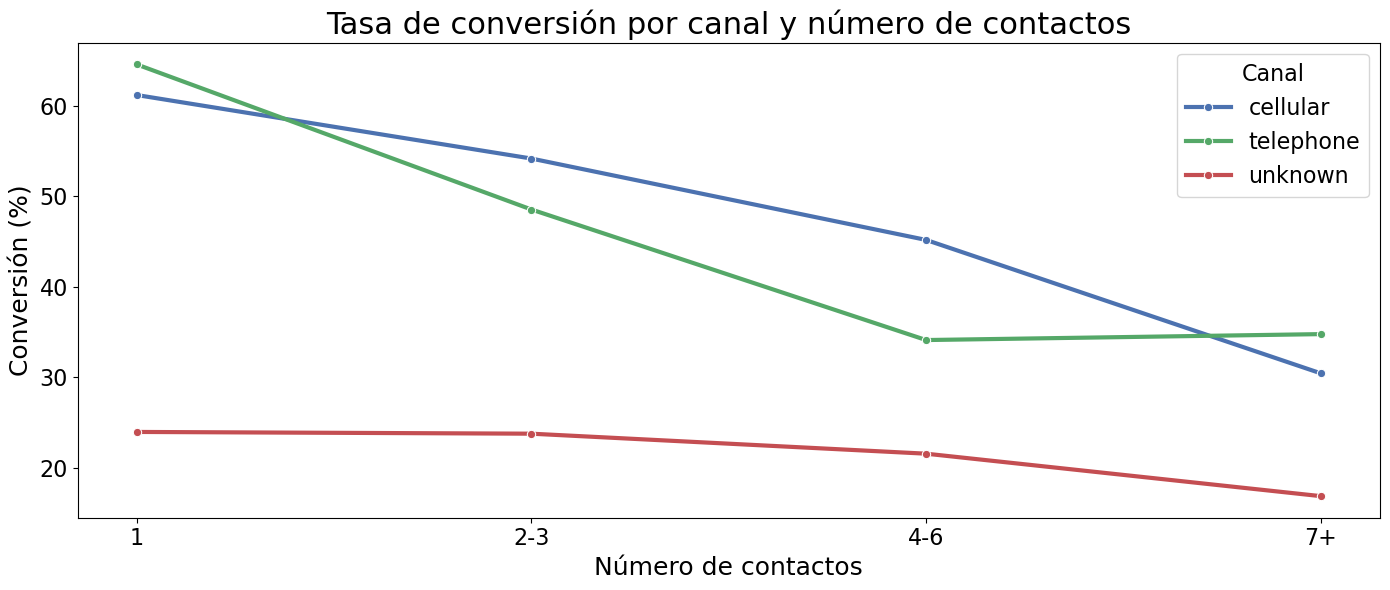

In [17]:
color_map = {
    "cellular": "#4C72B0",
    "telephone": "#55A868",
    "unknown": "#C44E52"
}

plt.figure(figsize=(14, 6))  

sns.lineplot(
    data=conversion_context,
    x="campaign_group",
    y="conversion_rate",
    hue="contact",
    palette=color_map,
    marker="o",
    linewidth=3
)

plt.title("Tasa de conversión por canal y número de contactos", fontsize=22)
plt.xlabel("Número de contactos", fontsize=18)
plt.ylabel("Conversión (%)", fontsize=18)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.legend(title="Canal", fontsize=16, title_fontsize=16)

plt.tight_layout()
plt.show()

In [18]:
#fig.write_html("grafico_lineas.html", auto_open=True)

El impacto del canal no es uniforme.
Observamos que el canal móvil es más eficaz en los primeros contactos, pero su rendimiento disminuye a medida que aumenta el número de intentos, evidenciando un efecto de saturación

### **Capa 3- Regresión logística (validación)**

### ***Objetivo:*** Validar el análisis controlando variables

In [19]:
# Variables
X = df_marketing[["contact", "campaign", "age"]]
y = df_marketing["deposit_bin"]

categorical = ["contact"]
numeric = ["campaign", "age"]

# Pipeline categórico
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Pipeline numérico
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocesador
preprocessor = ColumnTransformer([
    ("cat", categorical_pipeline, categorical),
    ("num", numeric_pipeline, numeric)
])

# Modelo
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Entrenamiento
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
# Evaluación básica
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.62147406733394

In [21]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefficients
}).sort_values(by="coef", ascending=False)

coef_df

,feature,coef
3,num__age,0.057461
0,cat__contact_telephone,-0.147891
2,num__campaign,-0.301908
1,cat__contact_unknown,-1.374004


Se ha construido un modelo de regresión logística como validación del análisis, incorporando variables de control como el número de contactos previos (campaign) y la edad (age). Esto permite aislar el efecto del tipo de contacto sobre la conversión, evitando atribuir las diferencias observadas únicamente al canal cuando pueden estar influenciadas por la intensidad de interacción o el perfil del cliente.

Los resultados confirman que tanto el tipo de contacto como el número de contactos influyen en la probabilidad de conversión, reforzando los patrones observados en el análisis descriptivo.

---

#### **Además de confirmar los resultados que ya veniamos observando decidimos de incorporar nuevas variables de control que nos ayuden a profuncdizar y entender que pueden estar impactando en que se contacte por móvil o por teléfono fijo**

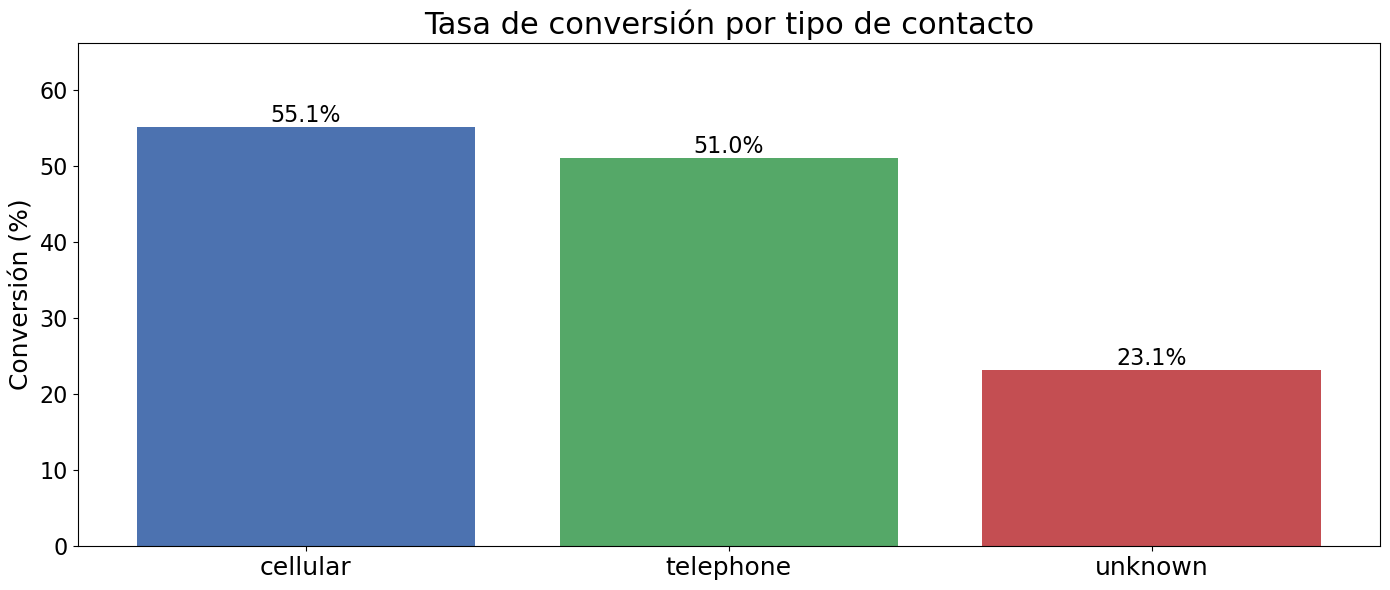

In [22]:
plt.figure(figsize=(14, 6))

bars = plt.bar(
    conversion_contact["contact"],
    conversion_contact["conversion_rate"],
    color=[color_map[c] for c in conversion_contact["contact"]]
)

plt.title("Tasa de conversión por tipo de contacto", fontsize=22)
plt.xlabel("")
plt.ylabel("Conversión (%)", fontsize=18)

plt.xticks(fontsize=18)
plt.yticks(fontsize=16)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=16
    )

plt.ylim(0, max(conversion_contact["conversion_rate"]) * 1.2)

plt.tight_layout()
plt.show()

---

## **Barras Comparativo**

In [23]:
df_marketing["campaign_group"] = pd.cut(
    df_marketing["campaign"],
    bins=[0, 1, 3, 6, 100],
    labels=["1 contacto", "2-3 contactos", "4-6 contactos", "7+ contactos"],
    include_lowest=True
)

/var/folders/jv/7q1fz7mx4p5cwq9vy_chsmxm0000gn/T/ipykernel_23800/3415107098.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_marketing.groupby(["contact", "campaign_group"])["deposit_bin"]


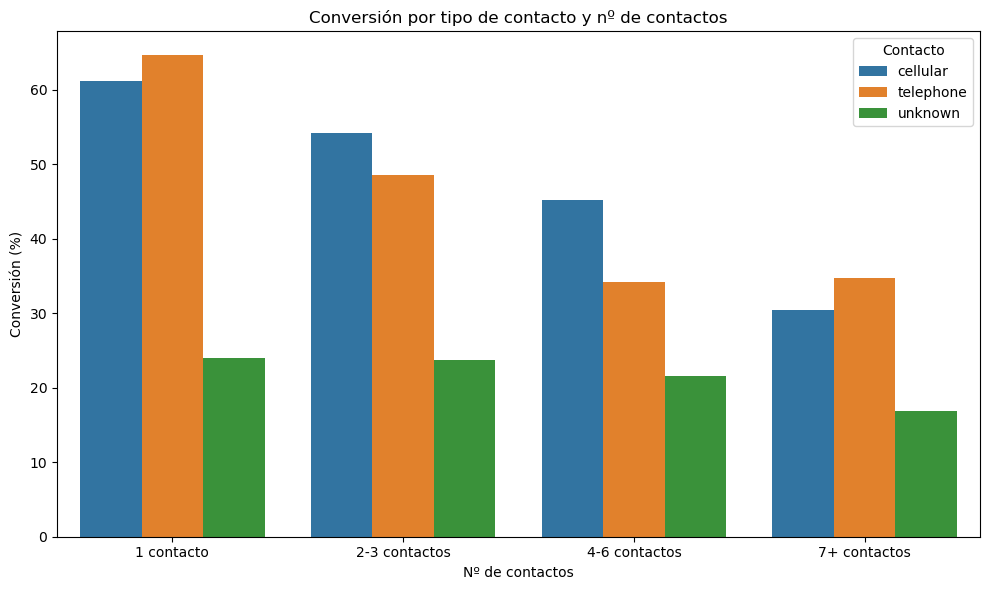

In [24]:

conversion = (
    df_marketing.groupby(["contact", "campaign_group"])["deposit_bin"]
    .mean()
    .reset_index()
)

conversion["conversion_rate"] = conversion["deposit_bin"] * 100

plt.figure(figsize=(10, 6))

sns.barplot(
    data=conversion,
    x="campaign_group",
    y="conversion_rate",
    hue="contact"
)

plt.title("Conversión por tipo de contacto y nº de contactos")
plt.xlabel("Nº de contactos")
plt.ylabel("Conversión (%)")
plt.legend(title="Contacto")
plt.tight_layout()
plt.show()

In [25]:
df_marketing["age_group"] = pd.cut(
    df_marketing["age"],
    bins=[0, 30, 45, 60, 100],
    labels=["<30", "30-45", "46-60", ">60"],
    include_lowest=True
)

In [26]:
df_marketing.groupby(["contact", "age_group"])["deposit_bin"].mean()

/var/folders/jv/7q1fz7mx4p5cwq9vy_chsmxm0000gn/T/ipykernel_23800/3006436634.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_marketing.groupby(["contact", "age_group"])["deposit_bin"].mean()


contact    age_group
cellular   <30          0.646254
           30-45        0.501778
           46-60        0.513300
           >60          0.843091
telephone  <30          0.494118
           30-45        0.397321
           46-60        0.427007
           >60          0.784530
unknown    <30          0.302198
           30-45        0.225318
           46-60        0.203869
           >60          0.000000
Name: deposit_bin, dtype: float64

---


## **Agregamos 'age'**

### **Código para integrar 'age'**

#### **Grupos de edad**

In [27]:
df_marketing["age_group"] = pd.cut(
    df_marketing["age"],
    bins=[0, 30, 45, 60, 100],
    labels=["<30", "30-45", "46-60", ">60"]
)

#### **Conversión segmentada**

In [28]:
conversion_age = (
    df_marketing.groupby(["age_group", "contact"])["deposit_bin"]
    .mean()
    .reset_index()
)

conversion_age["conversion_rate"] = conversion_age["deposit_bin"] * 100

/var/folders/jv/7q1fz7mx4p5cwq9vy_chsmxm0000gn/T/ipykernel_23800/2987417659.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_marketing.groupby(["age_group", "contact"])["deposit_bin"]


## **Gráfico de conversión por edad y tipo de contacto**

#### **Comparar canal dentro de cada grupo de edad**

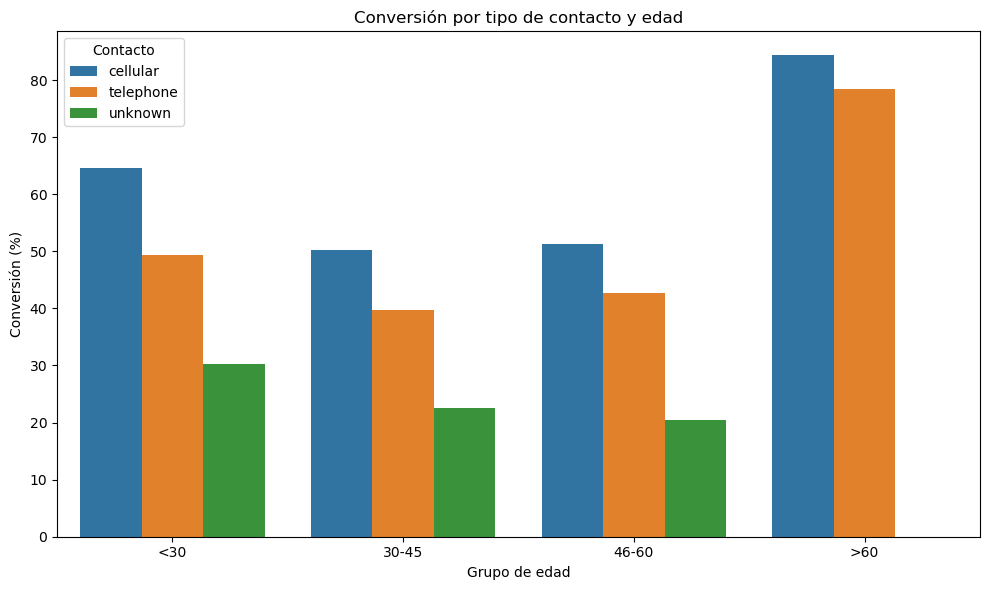

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=conversion_age,
    x="age_group",
    y="conversion_rate",
    hue="contact"
)

plt.title("Conversión por tipo de contacto y edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Conversión (%)")
plt.legend(title="Contacto")
plt.tight_layout()
plt.show()

---

## **Recomendaciones**

A partir de los resultados obtenidos, se recomienda priorizar el canal móvil en los primeros intentos de contacto, ya que presenta una mayor tasa de conversión inicial. Sin embargo, dado el efecto de saturación observado, se sugiere limitar el número de intentos y combinar estrategias con otros canales en fases posteriores. Además, sería recomendable analizar con mayor profundidad la categoría 'unknown' para reducir su impacto y mejorar la calidad del targeting.

---

# =========================
# ANÁLISIS SEMANA 260504
# =========================

## **OBJETIVO**

Analizar cómo influyen los días de la semana en la efectividad de nuestras campañas de marketing y qué días deberían ser priorizados para maximizar el éxito de nuestras estrategias de contacto.

## **1 - Carga de datos actualizados**

In [30]:
df_260504 = pd.read_parquet("../../Data/df_limpiado_260504.parquet")
df_marketing.copy()

df_marketing.head() 

,age,job,marital,education,default,balance,housing,loan,contact,day,...,duration,campaign,pdays,previous,poutcome,deposit,contactado_campania_previa,deposit_bin,campaign_group,age_group
0,59,administration,married,secondary,no,2343,yes,no,unknown,5,...,1042,1,NaN,0,sin_campania_previa,yes,0,1,1 contacto,46-60
1,56,administration,married,secondary,no,45,no,no,unknown,5,...,1467,1,NaN,0,sin_campania_previa,yes,0,1,1 contacto,46-60
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,...,1389,1,NaN,0,sin_campania_previa,yes,0,1,1 contacto,30-45
3,55,services,married,secondary,no,2476,yes,no,unknown,5,...,579,1,NaN,0,sin_campania_previa,yes,0,1,1 contacto,46-60
4,54,administration,married,tertiary,no,184,no,no,unknown,5,...,673,2,NaN,0,sin_campania_previa,yes,0,1,2-3 contactos,46-60


## **2 - Preparación de variables**

El CSV contiene `day` y `month`, pero no incluye directamente el año ni el día de la semana. Usamos la información del origen del dataset para reconstruir una fecha estimada dentro del periodo 2008-2010.

In [31]:
# Target binario
if "deposit_bin" not in df_marketing.columns:
    df_marketing["deposit_bin"] = df_marketing["deposit"].map({"yes": 1, "no": 0})

# Mapeo de meses
month_map = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4,
    "may": 5, "jun": 6, "jul": 7, "aug": 8,
    "sep": 9, "oct": 10, "nov": 11, "dec": 12
}

df_marketing["month_num"] = df_marketing["month"].map(month_map)

# Reconstrucción estimada del año.
# Partimos de 2008 y cambiamos de año cuando detectamos el paso de diciembre a enero.
years = []
current_year = 2008
previous_month = df_marketing["month_num"].iloc[0]

for month in df_marketing["month_num"]:
    if previous_month == 12 and month == 1:
        current_year += 1

    years.append(current_year)
    previous_month = month

df_marketing["year"] = years

# Construcción de fecha y día de la semana
df_marketing["date"] = pd.to_datetime(
    {
        "year": df_marketing["year"],
        "month": df_marketing["month_num"],
        "day": df_marketing["day"]
    },
    errors="coerce"
)

df_marketing["day_of_week"] = df_marketing["date"].dt.day_name()

# Traducción de días para presentar mejor el resultado
day_translation = {
    "Monday": "Lunes",
    "Tuesday": "Martes",
    "Wednesday": "Miércoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

df_marketing["dia_semana"] = df_marketing["day_of_week"].map(day_translation)

df_marketing[["day", "month", "year", "date", "dia_semana", "deposit"]].head()

,day,month,year,date,dia_semana,deposit
0,5,may,2008,2008-05-05,Lunes,yes
1,5,may,2008,2008-05-05,Lunes,yes
2,5,may,2008,2008-05-05,Lunes,yes
3,5,may,2008,2008-05-05,Lunes,yes
4,5,may,2008,2008-05-05,Lunes,yes


## **3 - Control de calidad de la reconstrucción temporal**

In [32]:
print("Fecha mínima estimada:", df_marketing["date"].min())
print("Fecha máxima estimada:", df_marketing["date"].max())
print("Fechas no reconstruidas:", df_marketing["date"].isna().sum())

df_marketing[["year", "month", "day", "date", "dia_semana"]].sample(10, random_state=42)

Fecha mínima estimada: 2008-05-05 00:00:00
Fecha máxima estimada: 2010-12-29 00:00:00
Fechas no reconstruidas: 0


,year,month,day,date,dia_semana
107,2008,may,20,2008-05-20,Martes
9775,2010,aug,8,2010-08-08,Domingo
3424,2010,apr,16,2010-04-16,Viernes
7945,2010,aug,22,2010-08-22,Domingo
6054,2010,may,8,2010-05-08,Sábado
8926,2010,aug,27,2010-08-27,Viernes
8016,2010,oct,18,2010-10-18,Lunes
10342,2010,jun,11,2010-06-11,Viernes
1718,2009,apr,30,2009-04-30,Jueves
4447,2010,may,16,2010-05-16,Domingo


## **4 - Validación adicional: conversión por año estimado y día de la semana**

Antes de hacer la recomendación final, comprobamos si la conversión cambia según el año estimado. Esta revisión es importante porque el CSV no trae el año real, sino que se reconstruyó a partir del rango temporal del dataset y el orden de los registros.

Si algunos años muestran conversiones del 100%, esos años pueden sesgar el análisis. Por eso esta comparación nos ayuda a justificar por qué el análisis de negocio se centra después en el año estimado 2010.

In [33]:
# Conversión media por año estimado y día de la semana
df_marketing.groupby(["year", "day_of_week"])["deposit_bin"].mean()

year  day_of_week
2008  Friday         1.000000
      Monday         1.000000
      Saturday       1.000000
      Sunday         1.000000
      Thursday       1.000000
      Tuesday        1.000000
      Wednesday      1.000000
2009  Friday         1.000000
      Monday         1.000000
      Thursday       1.000000
      Tuesday        1.000000
      Wednesday      1.000000
2010  Friday         0.255071
      Monday         0.831541
      Saturday       0.128854
      Sunday         0.094697
      Thursday       0.305556
      Tuesday        0.466667
      Wednesday      0.306178
Name: deposit_bin, dtype: float64

In [34]:
conversion_year_day = (
    df_marketing.groupby(["year", "day_of_week"])["deposit_bin"]
    .mean()
    .reset_index()
)

conversion_year_day["conversion_rate"] = conversion_year_day["deposit_bin"] * 100

conversion_year_day

,year,day_of_week,deposit_bin,conversion_rate
0,2008,Friday,1.000000,100.000000
1,2008,Monday,1.000000,100.000000
2,2008,Saturday,1.000000,100.000000
3,2008,Sunday,1.000000,100.000000
4,2008,Thursday,1.000000,100.000000
5,2008,Tuesday,1.000000,100.000000
6,2008,Wednesday,1.000000,100.000000
7,2009,Friday,1.000000,100.000000
8,2009,Monday,1.000000,100.000000
9,2009,Thursday,1.000000,100.000000


In [35]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

conversion_year_day["day_of_week"] = pd.Categorical(
    conversion_year_day["day_of_week"],
    categories=order,
    ordered=True
)

conversion_year_day = conversion_year_day.sort_values(["year", "day_of_week"])

conversion_year_day

,year,day_of_week,deposit_bin,conversion_rate
1,2008,Monday,1.000000,100.000000
5,2008,Tuesday,1.000000,100.000000
6,2008,Wednesday,1.000000,100.000000
4,2008,Thursday,1.000000,100.000000
0,2008,Friday,1.000000,100.000000
2,2008,Saturday,1.000000,100.000000
3,2008,Sunday,1.000000,100.000000
8,2009,Monday,1.000000,100.000000
10,2009,Tuesday,1.000000,100.000000
11,2009,Wednesday,1.000000,100.000000


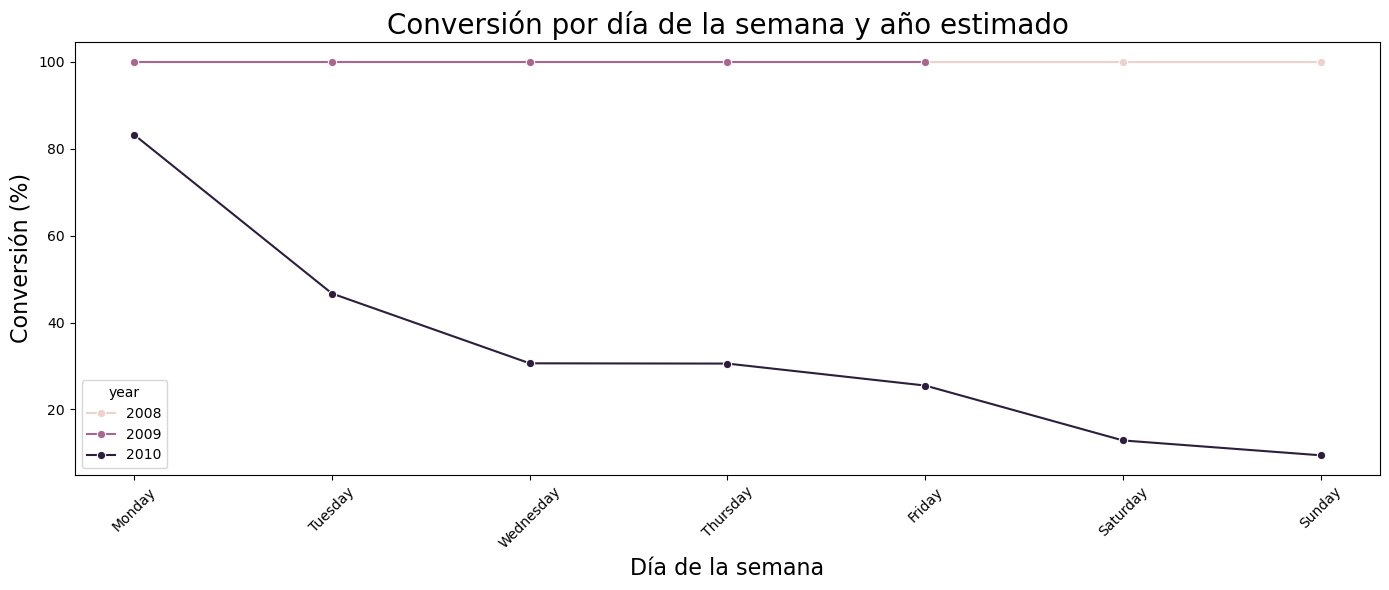

In [48]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=conversion_year_day,
    x="day_of_week",
    y="conversion_rate",
    hue="year",
    marker="o"
)

plt.title("Conversión por día de la semana y año estimado", fontsize=20)
plt.xlabel("Día de la semana", fontsize=16)
plt.ylabel("Conversión (%)", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Interpretación de la validación por año**

Al comparar la conversión por año estimado, se observa que los años 2008 y 2009 pueden mostrar tasas de conversión artificialmente altas, incluso cercanas o iguales al 100%. Esto no resulta realista para una campaña de marketing porque significaría que todos los contactos acabaron contratando el depósito.

Por este motivo, el rango 2008-2010 se utiliza para reconstruir la secuencia temporal y calcular el día de la semana, pero el análisis final de efectividad se realiza sobre el año estimado 2010, que contiene una mezcla más realista de respuestas `yes` y `no`.

## **5 - Análisis filtrado: conversión por día de la semana en 2010**

A partir de este punto trabajamos con `df_2010`, es decir, solo con los registros del año estimado 2010. Esto reduce el sesgo detectado en los años anteriores y permite obtener conclusiones más prudentes para negocio.

In [37]:
df_2010 = df_marketing[df_marketing["year"] == 2010].copy()

print("Filas del dataset completo:", df_marketing.shape[0])
print("Filas usadas para el análisis 2010:", df_2010.shape[0])

pd.crosstab(df_2010["deposit"], columns="registros")

Filas del dataset completo: 10987
Filas usadas para el análisis 2010: 7932


col_0,registros
deposit,
no,5698
yes,2234


In [38]:
conversion_2010 = (
    df_2010.groupby("day_of_week")["deposit_bin"]
    .mean()
    .reset_index()
)

conversion_2010["conversion_rate"] = conversion_2010["deposit_bin"] * 100

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

conversion_2010["day_of_week"] = pd.Categorical(
    conversion_2010["day_of_week"],
    categories=order,
    ordered=True
)

conversion_2010 = conversion_2010.sort_values("day_of_week")

conversion_2010

,day_of_week,deposit_bin,conversion_rate
1,Monday,0.831541,83.154122
5,Tuesday,0.466667,46.666667
6,Wednesday,0.306178,30.617787
4,Thursday,0.305556,30.555556
0,Friday,0.255071,25.507068
2,Saturday,0.128854,12.885375
3,Sunday,0.094697,9.469697


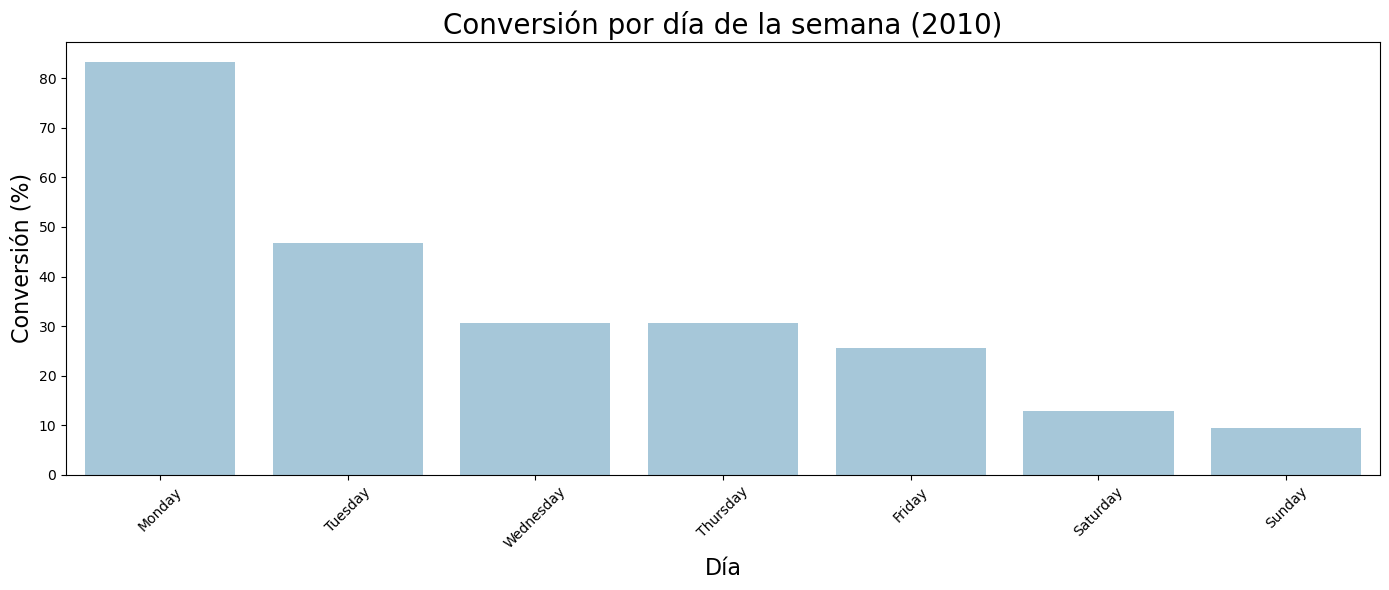

In [39]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=conversion_2010,
    x="day_of_week",
    y="conversion_rate",
    color="#9ecae1"
)

plt.title("Conversión por día de la semana (2010)", fontsize=20)
plt.xlabel("Día", fontsize=16)
plt.ylabel("Conversión (%)", fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **6 - Análisis principal: conversión y volumen por día de la semana en 2010**

Aquí incorporamos el punto clave del feedback: además de mirar la conversión, controlamos el **número de contactos** realizados en cada día. Este análisis se realiza sobre `df_2010` para evitar el sesgo detectado en los años estimados 2008 y 2009.

In [40]:
orden_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

resumen_dias = (
    df_2010.groupby("dia_semana", observed=True)
    .agg(
        contactos=("deposit_bin", "count"),
        conversiones=("deposit_bin", "sum"),
        tasa_conversion=("deposit_bin", "mean"),
        media_intentos_campaign=("campaign", "mean")
    )
    .reset_index()
)

resumen_dias["tasa_conversion"] = resumen_dias["tasa_conversion"] * 100
resumen_dias["peso_contactos"] = resumen_dias["contactos"] / resumen_dias["contactos"].sum() * 100

resumen_dias["dia_semana"] = pd.Categorical(
    resumen_dias["dia_semana"],
    categories=orden_dias,
    ordered=True
)

resumen_dias = resumen_dias.sort_values("dia_semana")

resumen_dias.round({
    "tasa_conversion": 2,
    "peso_contactos": 2,
    "media_intentos_campaign": 2
})

,dia_semana,contactos,conversiones,tasa_conversion,media_intentos_campaign,peso_contactos
2,Lunes,279,232,83.15,2.03,3.52
3,Martes,840,392,46.67,2.07,10.59
4,Miércoles,1473,451,30.62,2.62,18.57
1,Jueves,1656,506,30.56,2.34,20.88
6,Viernes,1627,415,25.51,2.45,20.51
5,Sábado,1265,163,12.89,2.83,15.95
0,Domingo,792,75,9.47,3.00,9.98


## **7 - Visualización: tasa de conversión vs número de contactos en 2010**

Este gráfico permite comparar el rendimiento porcentual de cada día con el volumen de contactos que lo sostiene.

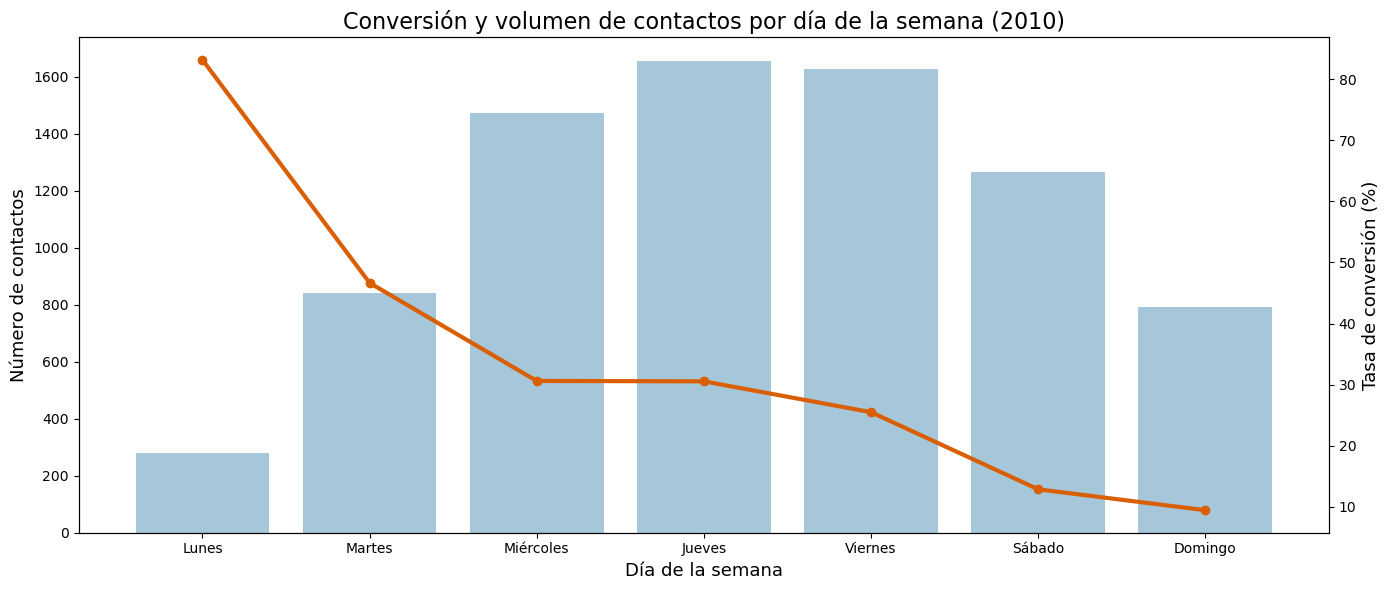

In [41]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Barras: volumen de contactos
sns.barplot(
    data=resumen_dias,
    x="dia_semana",
    y="contactos",
    ax=ax1,
    color="#9ecae1"
)

ax1.set_xlabel("Día de la semana", fontsize=13)
ax1.set_ylabel("Número de contactos", fontsize=13)
ax1.tick_params(axis="x", rotation=0)

# Línea: tasa de conversión
ax2 = ax1.twinx()
ax2.plot(
    resumen_dias["dia_semana"].astype(str),
    resumen_dias["tasa_conversion"],
    marker="o",
    linewidth=3,
    color="#d95f02"
)
ax2.set_ylabel("Tasa de conversión (%)", fontsize=13)

plt.title("Conversión y volumen de contactos por día de la semana (2010)", fontsize=16)
plt.tight_layout()
plt.show()

## **8 - Priorización de días para negocio con datos de 2010**

Para evitar priorizar un día solo porque tiene una conversión alta pero pocos contactos, clasificamos los días usando dos criterios:

1. Que la tasa de conversión esté por encima de la media global.
2. Que el volumen de contactos sea igual o superior a la mediana de contactos por día.

Así priorizamos días con buen rendimiento y suficiente base de datos.

In [42]:
conversion_global = df_2010["deposit_bin"].mean() * 100
mediana_contactos = resumen_dias["contactos"].median()

def clasificar_prioridad(row):
    if row["tasa_conversion"] >= conversion_global and row["contactos"] >= mediana_contactos:
        return "Prioridad alta"
    elif row["tasa_conversion"] >= conversion_global and row["contactos"] < mediana_contactos:
        return "Potencial, pero revisar volumen"
    elif row["tasa_conversion"] < conversion_global and row["contactos"] >= mediana_contactos:
        return "Volumen alto, optimizar mensaje"
    else:
        return "Prioridad baja"

resumen_dias["prioridad_negocio"] = resumen_dias.apply(clasificar_prioridad, axis=1)

ranking_dias = resumen_dias.sort_values(
    by=["prioridad_negocio", "tasa_conversion", "contactos"],
    ascending=[True, False, False]
)

print(f"Conversión global: {conversion_global:.2f}%")
print(f"Mediana de contactos por día: {mediana_contactos:.0f}")

ranking_dias[[
    "dia_semana",
    "contactos",
    "conversiones",
    "tasa_conversion",
    "peso_contactos",
    "media_intentos_campaign",
    "prioridad_negocio"
]].round({
    "tasa_conversion": 2,
    "peso_contactos": 2,
    "media_intentos_campaign": 2
})

Conversión global: 28.16%
Mediana de contactos por día: 1265


,dia_semana,contactos,conversiones,tasa_conversion,peso_contactos,media_intentos_campaign,prioridad_negocio
2,Lunes,279,232,83.15,3.52,2.03,"Potencial, pero revisar volumen"
3,Martes,840,392,46.67,10.59,2.07,"Potencial, pero revisar volumen"
4,Miércoles,1473,451,30.62,18.57,2.62,Prioridad alta
1,Jueves,1656,506,30.56,20.88,2.34,Prioridad alta
0,Domingo,792,75,9.47,9.98,3.00,Prioridad baja
6,Viernes,1627,415,25.51,20.51,2.45,"Volumen alto, optimizar mensaje"
5,Sábado,1265,163,12.89,15.95,2.83,"Volumen alto, optimizar mensaje"


## **9 - Análisis complementario 2010: día de la semana y canal de contacto**

Incluimos el canal como contexto, pero manteniendo el foco de negocio en los días de la semana.

In [43]:
conversion_day_contact = (
    df_2010.groupby(["dia_semana", "contact"], observed=True)
    .agg(
        contactos=("deposit_bin", "count"),
        conversiones=("deposit_bin", "sum"),
        tasa_conversion=("deposit_bin", "mean")
    )
    .reset_index()
)

conversion_day_contact["tasa_conversion"] = conversion_day_contact["tasa_conversion"] * 100
conversion_day_contact["dia_semana"] = pd.Categorical(
    conversion_day_contact["dia_semana"],
    categories=orden_dias,
    ordered=True
)

conversion_day_contact = conversion_day_contact.sort_values("dia_semana")
conversion_day_contact.round({"tasa_conversion": 2})

,dia_semana,contact,contactos,conversiones,tasa_conversion
6,Lunes,cellular,240,203,84.58
7,Lunes,telephone,26,21,80.77
8,Lunes,unknown,13,8,61.54
10,Martes,telephone,81,38,46.91
9,Martes,cellular,747,348,46.59
11,Martes,unknown,12,6,50.00
14,Miércoles,unknown,359,15,4.18
13,Miércoles,telephone,106,34,32.08
12,Miércoles,cellular,1008,402,39.88
3,Jueves,cellular,1176,439,37.33


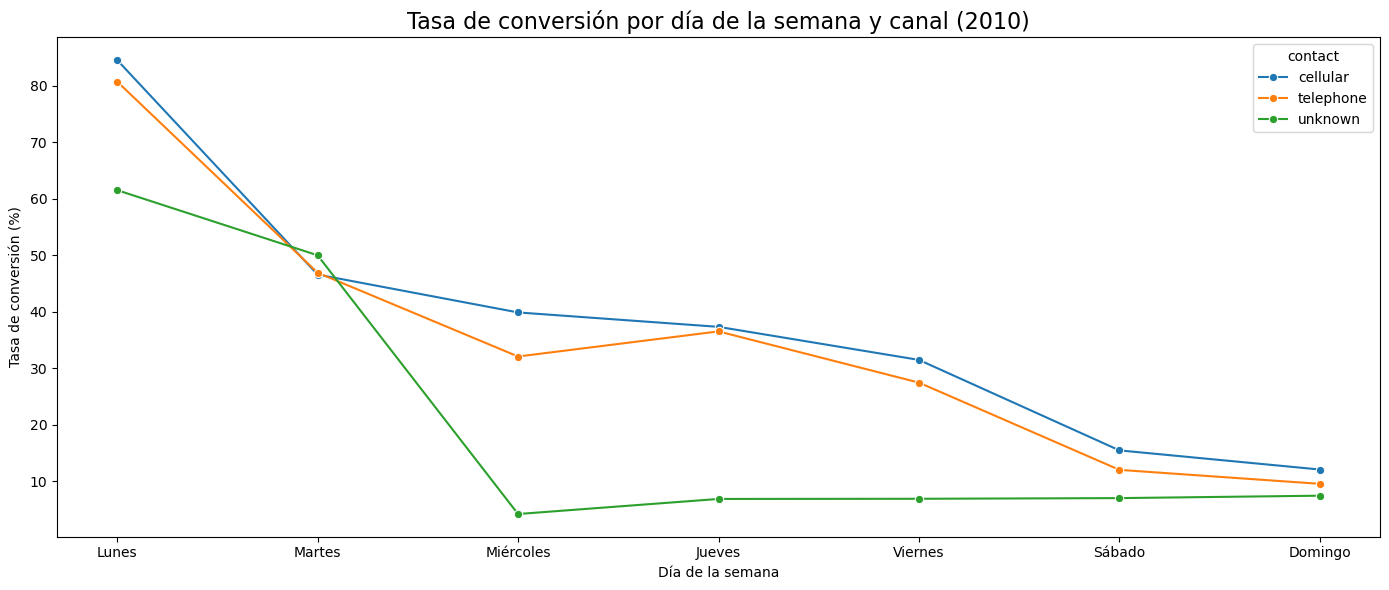

In [44]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=conversion_day_contact,
    x="dia_semana",
    y="tasa_conversion",
    hue="contact",
    marker="o"
)

plt.title("Tasa de conversión por día de la semana y canal (2010)", fontsize=16)
plt.xlabel("Día de la semana")
plt.ylabel("Tasa de conversión (%)")
plt.tight_layout()
plt.show()

## **10 - Conclusiones para negocio**

- En el año estimado 2010, el día de la semana influye en la efectividad de las campañas, pero la decisión no debe basarse únicamente en la tasa de conversión.
- El número de contactos funciona como control: una tasa alta con pocos contactos puede ser menos fiable que una tasa ligeramente menor con mucho mayor volumen.
- Los días prioritarios son aquellos que combinan **conversión superior a la media** y **volumen suficiente de contactos**.
- Los días con mucho volumen pero conversión inferior a la media no deben descartarse automáticamente; pueden ser oportunidades para mejorar el mensaje, el horario o la segmentación.
- Se recomienda priorizar los días clasificados como **Prioridad alta** y revisar los días marcados como **Potencial, pero revisar volumen** antes de tomar decisiones definitivas.

## **11 - Recomendación final**

Para maximizar el éxito de las estrategias de contacto, se recomienda concentrar los esfuerzos en los días de 2010 que presenten mejor equilibrio entre tasa de conversión y volumen de contactos.

En términos de negocio, esto significa que no basta con preguntar “qué día convierte más”, sino “qué día convierte bien y además tiene suficientes contactos como para que la conclusión sea representativa”.

La decisión de trabajar con 2010 se toma porque los años estimados 2008 y 2009 presentan conversiones artificialmente altas, lo que podría sesgar la recomendación final.